In [94]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier
import duckdb # for me to use sql even though it is not necessary with the way the datasets are given

In [58]:
#sklearn packages
import sklearn as sk
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
#test cell

## Data Definition

I am asked by Northern Lights Air (NLA) to run an analysis on their loyalty program. NLA ran a promotional campaign from Februrary 2018 (2018-02-01) until April 2018 (2018-04-31). NLA wants to improve their loyalty program, hence they want to know:
- What impact did the campaign have on the loyalty memberships? (Enrollment, Cancellation, Points redeemed etc.)
- What impact did the campaign have on booked flights? (in the summer, in general etc.)
- What impact did it have on customer churning?
- Was the campaign more successful towards certain demographics? (Gender, Education, Marital Status etc.)

## Exploratory Analysis

I will use SQL (for fun) to explore the data. 

**392936** total data entries index starting at 0

### Calendar 
This is a dataset that gives me everyday from 2012-01-01 (January 1, 2012) until 2018-12-31 (December 31, 2018). It gives me:
- Start of Year: first date of the year
- Start of Quarter: first date of the quarter it's in (Jan 1, Apr 1, Jul 1, Oct 1)
- Start of Month: first date of the month it's in

### Customer Flights Activity 
- Loyalty Number: **16737** unique members based on loyalty numbers
- Year
- Month
- Total Flights: Do not have to be loyalty member to fly
- Distance
- Points Accumulated
- Points Redeemed
- Dollar Cost Points Redeemed (CAD)

### Loyalty Program 
- Loyalty Number: **16737** unique members based on loyalty numbers
- Country: Canada (constant)
- Province
- City
- Postal Code
- Gender
- Education
- Salary (CAD): Contains NULL and negatives
- Marital Status
- Loyalty Card
- CLV
- Enrollment Type
- Enrollment Year
- Enrollment Month
- Cancellation Year: Contains NULL
- Cancellation Month: Contains NULL

### New Column Ideas
- tenure (months): lengths a loyalty number has their membership. Uses latest date in calendar.csv if they have not cancelled
- total flights: total number of flights flown per loyalty number
- total distance: total distance flown per loyalty number
- total points: total points accumulated per loyalty number
- total redeemed points: total points redeemed per loyalty number
- percentage redeemed: percentage of points redeemed (total redeemed points divided by total points. If no points accumulated then 0)
- enrollment date: combine enrollment year and month
- cancellation date: combine cancellation year and month
- salary missing: whether a salary entry is null (1 if yes, 0 if no)
- cancelled: whether or not the membership was cancelled (1 is yes, 0 is no)

I can see that we can **combine** Enrollment Year and Month together into one column, as well as Cancellation Year and Month. \
Can **combine** the two tables via Loyalty Number. \
Make two different tables, one that matches enrolment date to the calendar and one that matches cancellation date to calendar.\
Notice that column names are strings let's change that


In [ ]:
#Quick check to see the tables
calendar_df = pd.read_csv("Calendar.csv")
flight_df = pd.read_csv("Customer Flight Activity.csv")
loyalty_df = pd.read_csv("Customer Loyalty History.csv")

In [59]:
flight_df.head(2)

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0


In [60]:
loyalty_df.head(2)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN


### Due Diligence Data Clean and Check

- Null values
- Correct data types
- Correct formatting for datetime
- check multicollinearity
- check data variance

In [61]:
# #double checking cell 
# duckdb.sql(""" 
#     SELECT
#         cfa."Loyalty Number",
#         Year,
#         "Cancellation Year"
#     FROM read_csv_auto('Customer Flight Activity.csv') cfa
#     LEFT JOIN read_csv_auto('Customer Loyalty History.csv') clh
#         on cfa."Loyalty Number" = clh."Loyalty Number"
#     WHERE "Cancellation Year" < "Year"
#            """).df()

# Check for null valuesabs
duckdb.sql("""
SELECT 
    column_name,
    column_type,
    null_percentage
FROM(SUMMARIZE(
        SELECT *
        FROM read_csv_auto('Customer Flight Activity.csv') cfa
        LEFT JOIN read_csv_auto('Customer Loyalty History.csv') clh
            on cfa."Loyalty Number" = clh."Loyalty Number"))
""").df()

#87% of people have not churned away from the loyalty programabs
#25% null values 

,column_name,column_type,null_percentage
0,Loyalty Number,BIGINT,0.00
1,Year,BIGINT,0.00
2,Month,BIGINT,0.00
3,Total Flights,BIGINT,0.00
4,Distance,BIGINT,0.00
5,Points Accumulated,DOUBLE,0.00
6,Points Redeemed,BIGINT,0.00
7,Dollar Cost Points Redeemed,BIGINT,0.00
8,Loyalty Number,BIGINT,0.00
9,Country,VARCHAR,0.00


### Clean flight and loyalty dataframes

In [73]:
#to avoid repetition we can aggregate the stats of each distinct loyalty number via summation
#assign it to dataframe called "flight"
flight = duckdb.sql("""
SELECT 
    "Loyalty Number",
    SUM("Total Flights") AS "Total Flights",
    SUM(Distance) AS "Total Distance",
    SUM("Points Accumulated") AS "Total Points",
    SUM("Points Redeemed") AS "Total Redeemed Points",
    CASE WHEN "Total Points" = 0 THEN 0 ELSE ROUND("Total Redeemed Points" / "Total Points", 3)*100 END AS "Percentage Redeemed (%)"
FROM flight_df 
GROUP BY "Loyalty Number" 
ORDER BY "Loyalty Number"
""").df()

loyalty = duckdb.sql("""
SELECT * EXCLUDE("Postal Code", "City", "Country", "Enrollment Year", "Enrollment Month", "Cancellation Year", "Cancellation Month"),
    MAKE_DATE("Enrollment Year", "Enrollment Month", 1) AS "Enrollment Date",
    MAKE_DATE("Cancellation Year", "Cancellation Month", 1) AS "Cancellation Date",
    CASE WHEN ("Cancellation Year" AND "Cancellation Month") IS NULL THEN 0 ELSE 1 END AS Cancelled,
    CASE WHEN Salary IS NULL THEN 'Yes' ELSE 'No' END AS Salary_Missing,
    DATE_DIFF('month', "Enrollment Date", (SELECT MAX(Date) FROM read_csv_auto("Calendar.csv"))) AS "tenure"
FROM read_csv_auto("Customer Loyalty History.csv") 
""").df()

### Main Dataframe `main_df`

In [74]:
#Join tables 
#Concat Enrollment and Cancellation Month and Year together
#We use day as 01 
#Cancelled is the target (Y)
df = duckdb.sql(""" 
    SELECT * EXCLUDE ("Enrollment Date", "Cancellation Date", "Loyalty Number")
    FROM loyalty l
    LEFT JOIN flight f USING ("Loyalty Number")
    ORDER BY l."Loyalty Number"
           """).df()

## Decision Tree Analysis

- `main_df` is the df we will be using that has joined tables between loyalty history and flight activity
- 

In [75]:
df.head()

,Province,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Cancelled,Salary_Missing,tenure,Total Flights,Total Distance,Total Points,Total Redeemed Points,Percentage Redeemed (%)
0,Alberta,Female,Bachelor,92552,Married,Aurora,7919.20,Standard,0,No,28,46.0,81190.0,81190.0,1513.0,1.9
1,Ontario,Male,College,<NA>,Single,Nova,2887.74,Standard,0,Yes,69,51.0,68918.0,68918.0,1195.0,1.7
2,British Columbia,Female,College,<NA>,Divorced,Nova,2838.07,Standard,0,Yes,29,47.0,72856.0,72856.0,593.0,0.8
3,British Columbia,Male,Bachelor,63253,Married,Star,4170.57,Standard,0,No,40,22.0,38236.0,38236.0,861.0,2.3
4,Ontario,Female,Bachelor,91163,Divorced,Star,6622.05,Standard,0,No,59,37.0,54997.0,54997.0,1007.0,1.8


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Province                 16737 non-null  str    
 1   Gender                   16737 non-null  str    
 2   Education                16737 non-null  str    
 3   Salary                   12499 non-null  Int64  
 4   Marital Status           16737 non-null  str    
 5   Loyalty Card             16737 non-null  str    
 6   CLV                      16737 non-null  float64
 7   Enrollment Type          16737 non-null  str    
 8   Cancelled                16737 non-null  int32  
 9   Salary_Missing           16737 non-null  str    
 10  tenure                   16737 non-null  int64  
 11  Total Flights            16737 non-null  float64
 12  Total Distance           16737 non-null  float64
 13  Total Points             16737 non-null  float64
 14  Total Redeemed Points    16737 no

In [77]:
df.describe()

,Salary,CLV,Cancelled,tenure,Total Flights,Total Distance,Total Points,Total Redeemed Points,Percentage Redeemed (%)
count,12499.0,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000
mean,79245.609409,7988.896536,0.123499,38.292346,30.400191,45579.359921,47592.100884,734.932903,1.614483
std,35008.297285,6860.982280,0.329019,23.605926,16.865558,26092.338663,30391.859064,716.589736,2.565999
min,-58486.0,1898.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,59246.5,3980.840000,0.000000,17.000000,20.000000,28495.000000,28718.000000,0.000000,0.000000
50%,73455.0,5780.180000,0.000000,37.000000,34.000000,49445.000000,49885.000000,568.000000,1.200000
75%,88517.5,8940.580000,0.000000,59.000000,42.000000,62911.000000,63812.000000,1167.000000,2.300000
max,407228.0,83325.380000,1.000000,80.000000,106.000000,178858.000000,268287.000000,4479.000000,119.400000


In [83]:
df["Salary"].min()

np.int64(-58486)

In [85]:
df["Salary"] = df["Salary"].abs()

In [92]:
df.describe().min()

Salary                      9081.0
CLV                        1898.01
Cancelled                      0.0
tenure                         0.0
Total Flights                  0.0
Total Distance                 0.0
Total Points                   0.0
Total Redeemed Points          0.0
Percentage Redeemed (%)        0.0
dtype: Float64

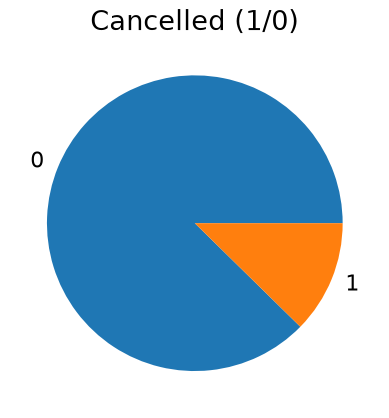

In [97]:
df["Cancelled"].value_counts().plot(kind = "pie")
plt.title("Cancelled (1/0)")
plt.ylabel("")
plt.show()

In [ ]:
#First let's make a decision tree using xgboost since it works with categorical variables

X = df.drop(columns = ['Cancelled'])
y = df['Cancelled']

for col in X.select_dtypes(include = ['object', 'str']).columns: #turn the string variables into category variables
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 123)

param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, 12, 15, None]
}

grid = GridSearchCV(
    xgb.XGBClassifier(),
    param_grid,
    cv = 10,
    scoring = 'neg_mean_squared_error'
)

grid.fit(X_train, y_train)
print(grid.best_params_) #max depth 3 is best
print(round(grid.best_score_, 3))

In [ ]:
model = xgb.XGBClassifier(max_depth = 3)
model.fit(X_train, y_train)
print(f"Error on test set: {1 - model.score(X_test, y_test):.2f} which is comparable to the cross validation error "
      f"{-1*grid.best_score_:.2f}")